# Анализ результатов эксперимента: сравнение различных наборов признаков для глобальной модели CatBoost на данных M4 Monthly

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, os.path.abspath('..'))

import config

sns.set_theme(style='whitegrid', font_scale=1.1)
RESULTS = config.RESULTS_DIR

metrics_overall = pd.read_csv(os.path.join(RESULTS, 'metrics_overall.csv'))
metrics_season  = pd.read_csv(os.path.join(RESULTS, 'metrics_by_seasonality.csv'))
metrics_horizon = pd.read_csv(os.path.join(RESULTS, 'metrics_by_horizon.csv'))
season_info     = pd.read_csv(os.path.join(RESULTS, 'seasonality_info.csv'))

with open(os.path.join(RESULTS, 'predictions.pkl'), 'rb') as f:
    all_preds = pickle.load(f)
with open(os.path.join(RESULTS, 'test_actuals.pkl'), 'rb') as f:
    test_actuals = pickle.load(f)
with open(os.path.join(RESULTS, 'train_data.pkl'), 'rb') as f:
    train_data = pickle.load(f)


## 1. Описание данных

In [2]:
print('Распределение рядов по силе сезонности:')
print(season_info['category'].value_counts().to_string())
print()
print(season_info['strength'].describe())

Распределение рядов по силе сезонности:
category
weak      50
medium    50
strong    50

count    150.000000
mean       0.490551
std        0.308022
min        0.000000
25%        0.230163
50%        0.503345
75%        0.781040
max        0.952497
Name: strength, dtype: float64


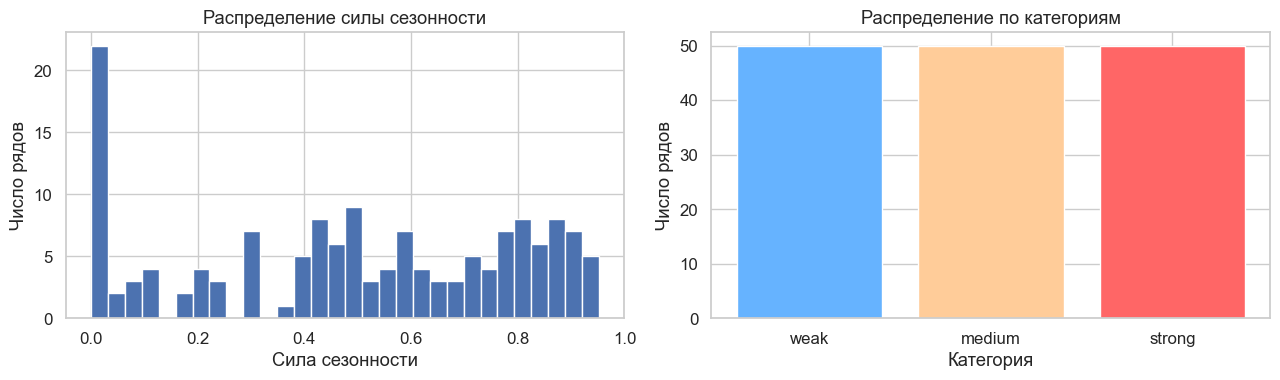

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(season_info['strength'], bins=30, edgecolor='white')
axes[0].set_xlabel('Сила сезонности')
axes[0].set_ylabel('Число рядов')
axes[0].set_title('Распределение силы сезонности')

cat_order = ['weak', 'medium', 'strong']
counts = season_info['category'].value_counts().reindex(cat_order, fill_value=0)
axes[1].bar(counts.index, counts.values, color=['#66b3ff', '#ffcc99', '#ff6666'])
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Число рядов')
axes[1].set_title('Распределение по категориям')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'seasonality_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### Примеры рядов с разной силой сезонности и их ACF

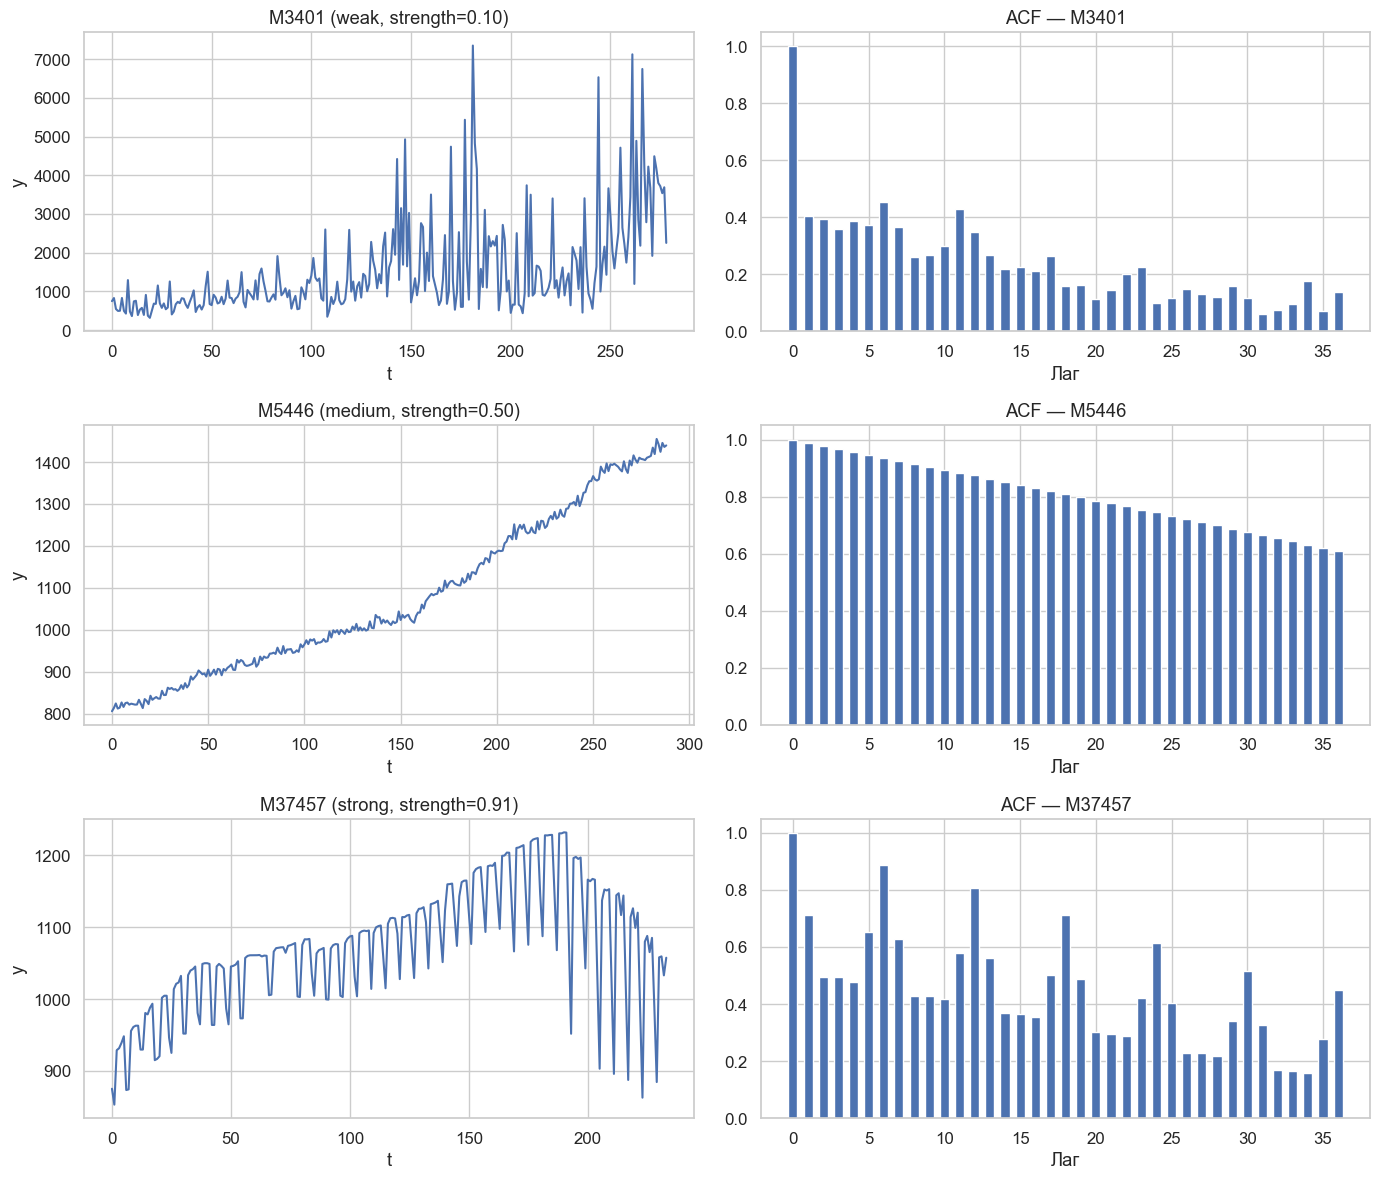

In [4]:
from statsmodels.tsa.stattools import acf

examples = {}
for cat in cat_order:
    sub = season_info[season_info['category'] == cat]
    if len(sub) > 0:
        examples[cat] = sub.iloc[len(sub)//2]['unique_id']

fig, axes = plt.subplots(len(examples), 2, figsize=(14, 4 * len(examples)))
if len(examples) == 1:
    axes = axes[np.newaxis, :]

for i, (cat, uid) in enumerate(examples.items()):
    vals = train_data[uid]
    axes[i, 0].plot(vals)
    axes[i, 0].set_title(f'{uid} ({cat}, strength={season_info.loc[season_info["unique_id"]==uid, "strength"].values[0]:.2f})')
    axes[i, 0].set_xlabel('t')
    axes[i, 0].set_ylabel('y')

    nlags = min(36, len(vals) // 2 - 1)
    acf_vals = acf(vals, nlags=nlags, fft=True)
    axes[i, 1].bar(range(nlags + 1), acf_vals, width=0.6)
    axes[i, 1].axhline(0, color='black', linewidth=0.5)
    axes[i, 1].set_title(f'ACF - {uid}')
    axes[i, 1].set_xlabel('Лаг')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'example_series_acf.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Общее сравнение методов

In [5]:
display(metrics_overall.sort_values('sMAPE_mean').reset_index(drop=True))

,method,sMAPE_mean,sMAPE_median,MASE_mean,MASE_median
0,AutoTheta,10.105751,4.669843,0.976316,0.842640
1,AutoETS,10.689747,4.602478,0.976273,0.856331
2,CB_lags_seasonal_calendar,11.268312,5.230754,1.146508,0.959247
3,CB_lags_seasonal,11.282028,5.528915,1.137164,0.972356
4,CB_lags_seasonal_fourier,11.282028,5.528915,1.137164,0.972356
5,CB_lags_calendar,11.423046,5.465154,1.173448,1.006579
6,CB_lags_only,11.468821,5.228655,1.164123,1.000478
7,CB_lags_fourier,11.468821,5.228655,1.164123,1.000478
8,Naive,12.046664,4.970477,1.218257,0.989270
9,SeasonalNaive,12.048441,6.177364,1.308496,1.092283


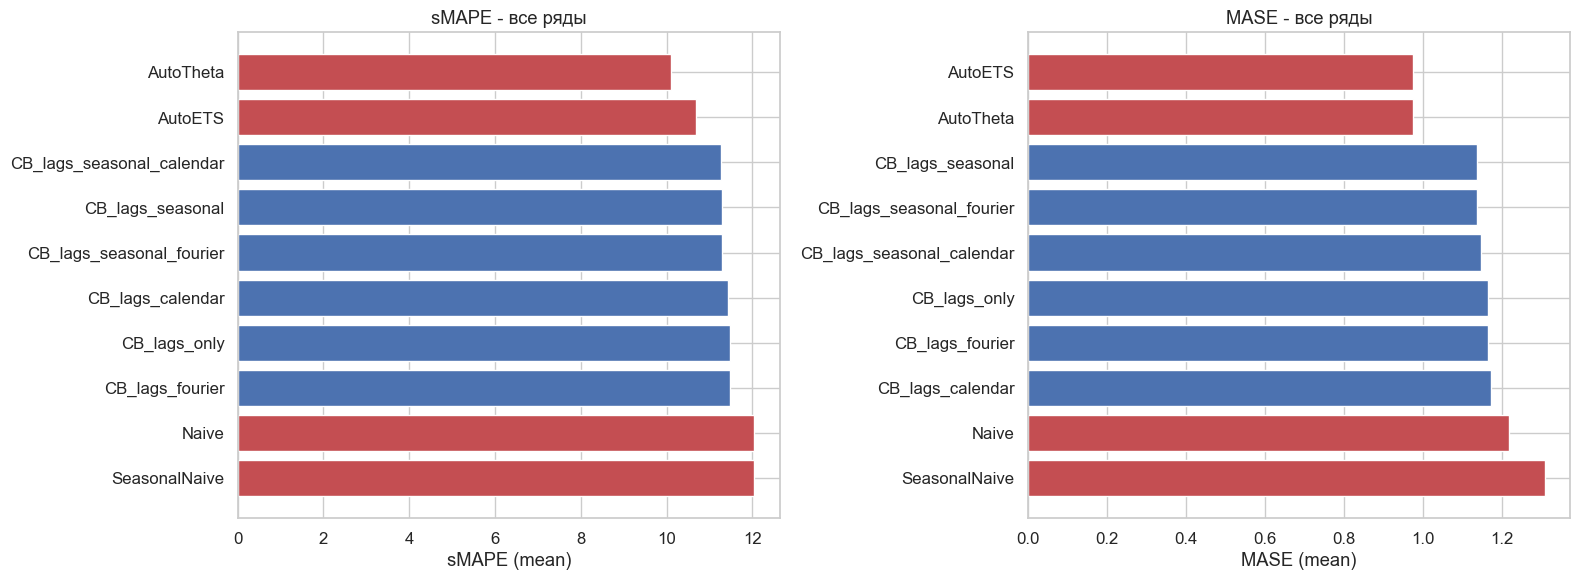

Синий - CatBoost, красный - бейзлайны


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = metrics_overall.sort_values('sMAPE_mean')['method']

colors = []
for m in order:
    if m.startswith('CB_'):
        colors.append('#4c72b0')
    else:
        colors.append('#c44e52')

axes[0].barh(order, metrics_overall.set_index('method').loc[order, 'sMAPE_mean'], color=colors)
axes[0].set_xlabel('sMAPE (mean)')
axes[0].set_title('sMAPE - все ряды')
axes[0].invert_yaxis()

order_m = metrics_overall.sort_values('MASE_mean')['method']
colors_m = ['#4c72b0' if m.startswith('CB_') else '#c44e52' for m in order_m]
axes[1].barh(order_m, metrics_overall.set_index('method').loc[order_m, 'MASE_mean'], color=colors_m)
axes[1].set_xlabel('MASE (mean)')
axes[1].set_title('MASE - все ряды')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'overall_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Синий - CatBoost, красный - бейзлайны')

## 3. Влияние силы сезонности

In [7]:
pivot_smape = metrics_season.pivot_table(
    index='method', columns='seasonality', values='sMAPE_mean')
pivot_smape = pivot_smape.reindex(columns=cat_order)

pivot_mase = metrics_season.pivot_table(
    index='method', columns='seasonality', values='MASE_mean')
pivot_mase = pivot_mase.reindex(columns=cat_order)

print('sMAPE по категориям сезонности:')
display(pivot_smape.round(2))
print()
print('MASE по категориям сезонности:')
display(pivot_mase.round(2))

sMAPE по категориям сезонности:


seasonality,weak,medium,strong
method,,,
AutoETS,14.19,11.55,6.34
AutoTheta,12.93,10.73,6.66
CB_lags_calendar,14.59,12.61,7.08
CB_lags_fourier,14.73,12.49,7.19
CB_lags_only,14.73,12.49,7.19
CB_lags_seasonal,14.48,12.61,6.76
CB_lags_seasonal_calendar,14.12,12.75,6.93
CB_lags_seasonal_fourier,14.48,12.61,6.76
Naive,13.32,14.72,8.09



MASE по категориям сезонности:


seasonality,weak,medium,strong
method,,,
AutoETS,0.99,0.93,1.00
AutoTheta,1.01,0.84,1.07
CB_lags_calendar,1.19,1.04,1.28
CB_lags_fourier,1.17,1.01,1.31
CB_lags_only,1.17,1.01,1.31
CB_lags_seasonal,1.14,1.04,1.23
CB_lags_seasonal_calendar,1.14,1.05,1.26
CB_lags_seasonal_fourier,1.14,1.04,1.23
Naive,1.03,1.12,1.50


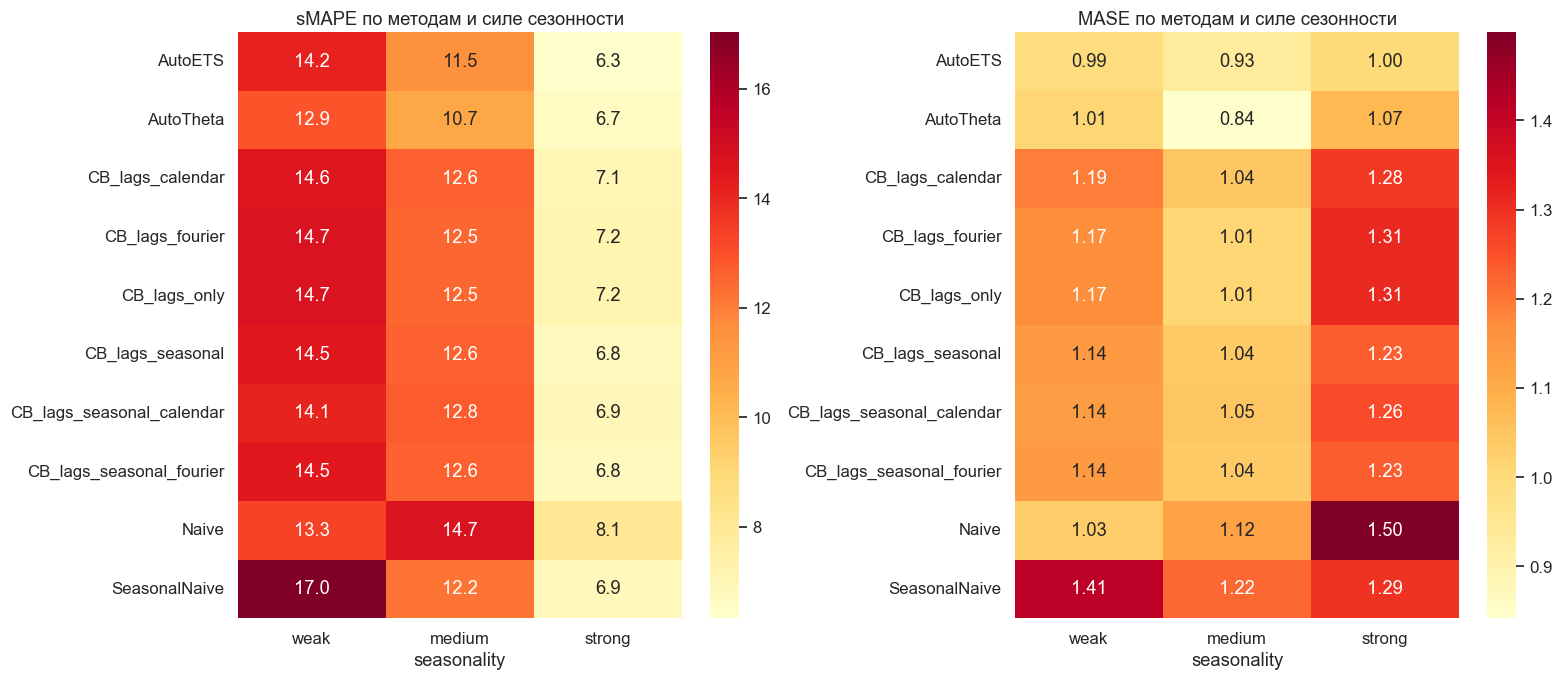

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pivot_smape, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('sMAPE по методам и силе сезонности')
axes[0].set_ylabel('')

sns.heatmap(pivot_mase, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('MASE по методам и силе сезонности')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'heatmap_seasonality.png'), dpi=150, bbox_inches='tight')
plt.show()

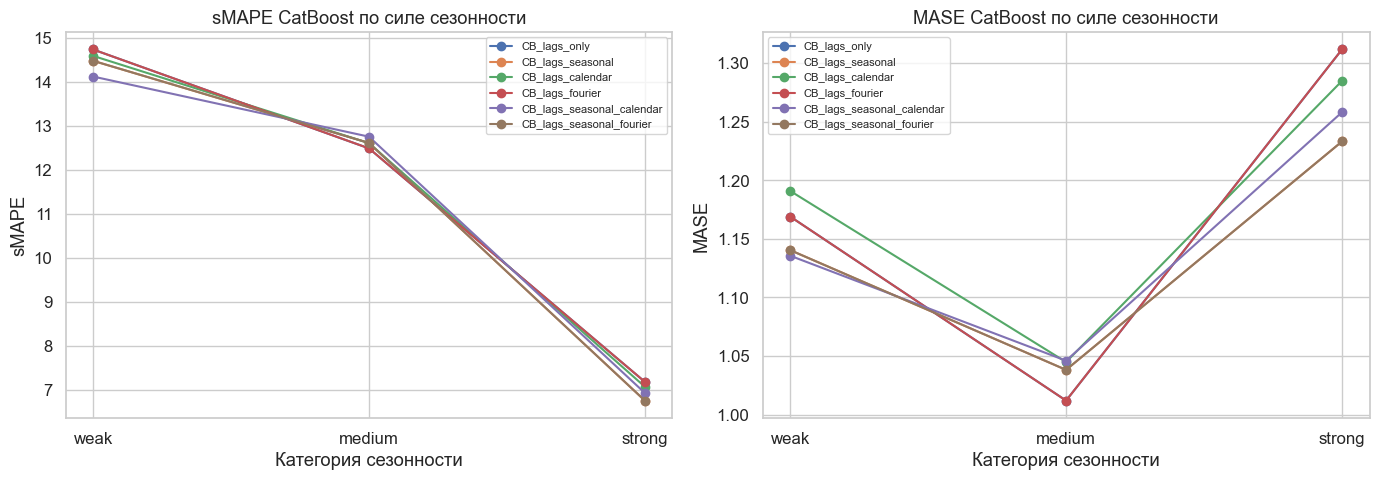

In [9]:
cb_methods = [m for m in metrics_season['method'].unique() if m.startswith('CB_')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for m in cb_methods:
    sub = metrics_season[metrics_season['method'] == m]
    sub = sub.set_index('seasonality').reindex(cat_order)
    axes[0].plot(cat_order, sub['sMAPE_mean'], marker='o', label=m)
    axes[1].plot(cat_order, sub['MASE_mean'], marker='o', label=m)

axes[0].set_title('sMAPE CatBoost по силе сезонности')
axes[0].set_xlabel('Категория сезонности')
axes[0].set_ylabel('sMAPE')
axes[0].legend(fontsize=8)

axes[1].set_title('MASE CatBoost по силе сезонности')
axes[1].set_xlabel('Категория сезонности')
axes[1].set_ylabel('MASE')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'catboost_by_seasonality.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Зависимость от горизонта прогнозирования

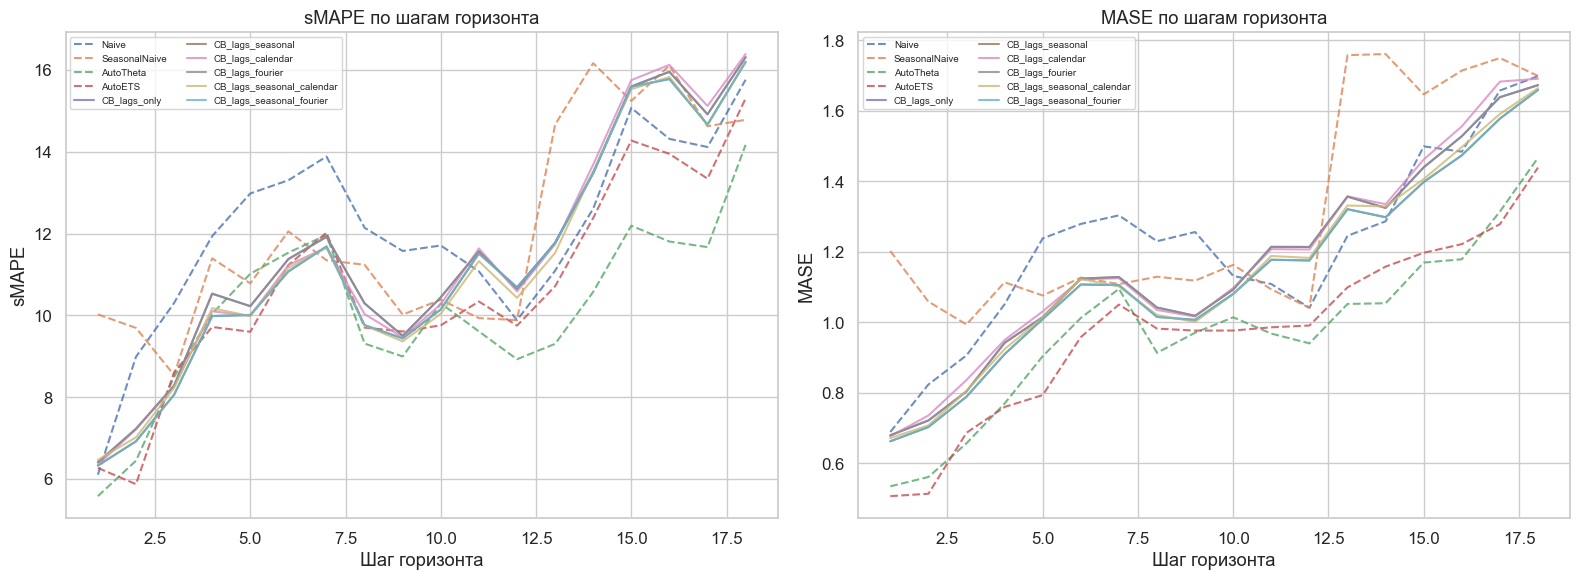

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for method in metrics_horizon['method'].unique():
    sub = metrics_horizon[metrics_horizon['method'] == method]
    style = '-' if method.startswith('CB_') else '--'
    axes[0].plot(sub['horizon_step'], sub['sMAPE_mean'], style, label=method, alpha=0.8)
    axes[1].plot(sub['horizon_step'], sub['MASE_mean'], style, label=method, alpha=0.8)

axes[0].set_xlabel('Шаг горизонта')
axes[0].set_ylabel('sMAPE')
axes[0].set_title('sMAPE по шагам горизонта')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('Шаг горизонта')
axes[1].set_ylabel('MASE')
axes[1].set_title('MASE по шагам горизонта')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'metrics_by_horizon.png'), dpi=150, bbox_inches='tight')
plt.show()

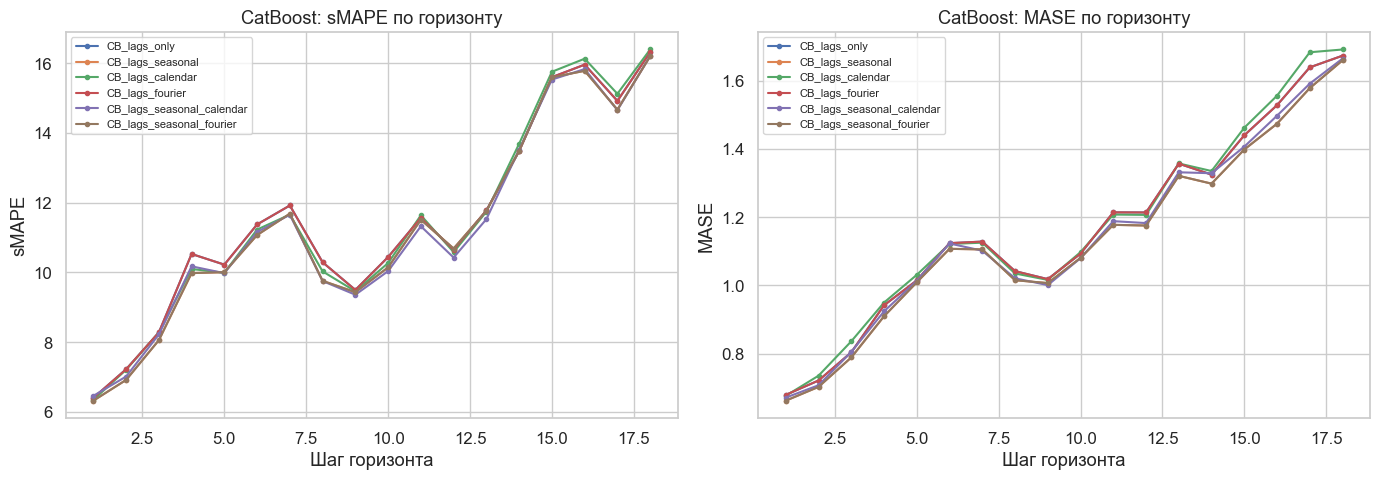

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for m in cb_methods:
    sub = metrics_horizon[metrics_horizon['method'] == m]
    axes[0].plot(sub['horizon_step'], sub['sMAPE_mean'], marker='.', label=m)
    axes[1].plot(sub['horizon_step'], sub['MASE_mean'], marker='.', label=m)

axes[0].set_xlabel('Шаг горизонта')
axes[0].set_ylabel('sMAPE')
axes[0].set_title('CatBoost: sMAPE по горизонту')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Шаг горизонта')
axes[1].set_ylabel('MASE')
axes[1].set_title('CatBoost: MASE по горизонту')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'catboost_by_horizon.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Ранние и поздние горизонты: какой набор признаков лидирует?

In [12]:
early = metrics_horizon[metrics_horizon['horizon_step'] <= 6]
late  = metrics_horizon[metrics_horizon['horizon_step'] > 12]

early_agg = early.groupby('method')[['sMAPE_mean', 'MASE_mean']].mean()
late_agg  = late.groupby('method')[['sMAPE_mean', 'MASE_mean']].mean()

comparison = pd.DataFrame({
    'sMAPE_early': early_agg['sMAPE_mean'],
    'sMAPE_late': late_agg['sMAPE_mean'],
    'MASE_early': early_agg['MASE_mean'],
    'MASE_late': late_agg['MASE_mean'],
}).round(3)

print('Сравнение ранних (h<=6) и поздних (h>12) горизонтов:')
display(comparison.sort_values('sMAPE_early'))

Сравнение ранних (h<=6) и поздних (h>12) горизонтов:


,sMAPE_early,sMAPE_late,MASE_early,MASE_late
method,,,,
AutoETS,8.548,13.327,0.703,1.232
CB_lags_seasonal,8.727,14.582,0.863,1.455
CB_lags_seasonal_fourier,8.727,14.582,0.863,1.455
CB_lags_seasonal_calendar,8.836,14.543,0.874,1.470
AutoTheta,8.850,11.618,0.740,1.206
CB_lags_calendar,8.859,14.803,0.892,1.514
CB_lags_fourier,9.007,14.672,0.881,1.493
CB_lags_only,9.007,14.672,0.881,1.493
SeasonalNaive,10.414,15.265,1.095,1.721


## 6. Примеры прогнозов

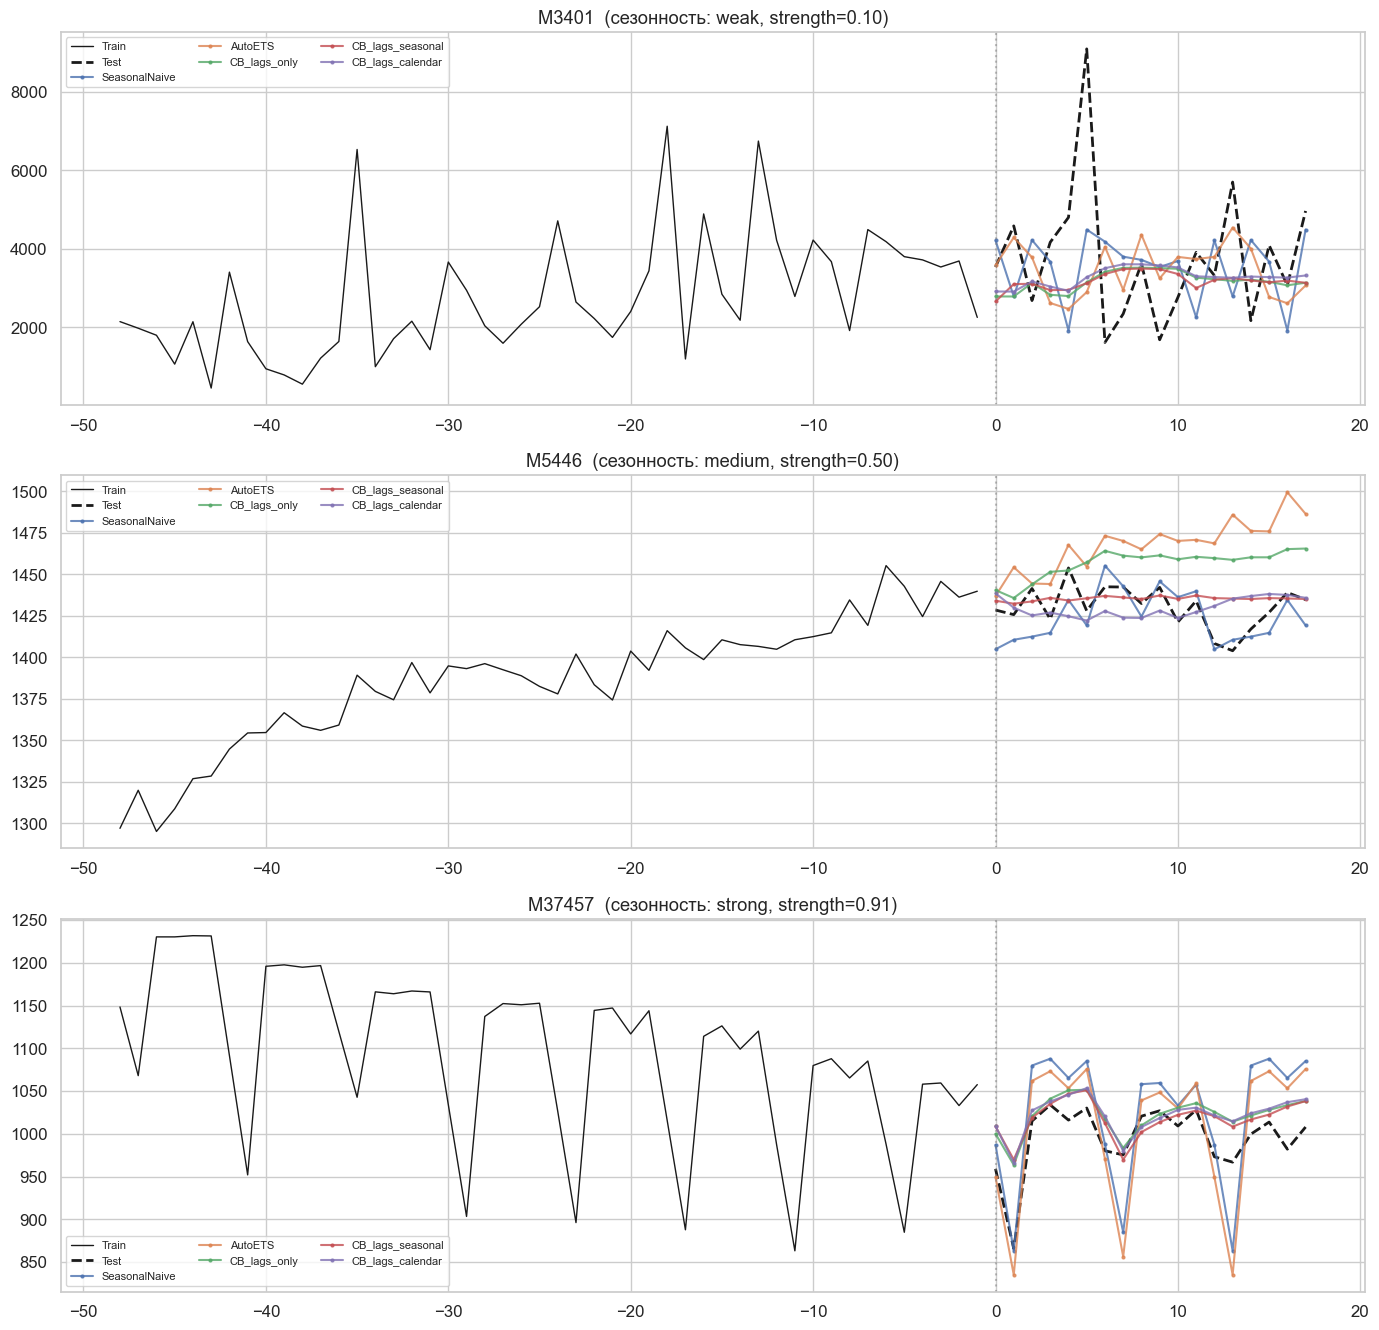

In [13]:
show_methods = ['SeasonalNaive', 'AutoETS']
show_methods += [m for m in all_preds if m.startswith('CB_')][:3]

example_uids = list(examples.values())[:3]

fig, axes = plt.subplots(len(example_uids), 1, figsize=(14, 4.5 * len(example_uids)))
if len(example_uids) == 1:
    axes = [axes]

for i, uid in enumerate(example_uids):
    ax = axes[i]
    train_vals = train_data[uid]
    test_vals  = test_actuals[uid]
    H = len(test_vals)

    ctx = min(48, len(train_vals))
    t_train = range(-ctx, 0)
    t_test  = range(0, H)

    ax.plot(t_train, train_vals[-ctx:], 'k-', label='Train', linewidth=1)
    ax.plot(t_test, test_vals, 'k--', label='Test', linewidth=2)

    for method in show_methods:
        if uid in all_preds.get(method, {}):
            ax.plot(t_test, all_preds[method][uid], marker='.', markersize=4, label=method, alpha=0.8)

    cat = season_info.loc[season_info['unique_id'] == uid, 'category'].values[0]
    st  = season_info.loc[season_info['unique_id'] == uid, 'strength'].values[0]
    ax.set_title(f'{uid}  (сезонность: {cat}, strength={st:.2f})')
    ax.legend(fontsize=8, ncol=3)
    ax.axvline(0, color='grey', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'example_forecasts.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Выводы

### Общие результаты

Сравним лучший и худший наборы признаков CatBoost, а также бейзлайны.

In [15]:
cb_overall = metrics_overall[metrics_overall['method'].str.startswith('CB_')].copy()
bl_overall = metrics_overall[~metrics_overall['method'].str.startswith('CB_')].copy()

best_cb_smape = cb_overall.loc[cb_overall['sMAPE_mean'].idxmin()]
worst_cb_smape = cb_overall.loc[cb_overall['sMAPE_mean'].idxmax()]
best_bl_smape = bl_overall.loc[bl_overall['sMAPE_mean'].idxmin()]

print('Лучший CatBoost (по sMAPE)')
print(f"  {best_cb_smape['method']}: sMAPE={best_cb_smape['sMAPE_mean']:.2f}, MASE={best_cb_smape['MASE_mean']:.3f}")
print(f'Худший CatBoost')
print(f"  {worst_cb_smape['method']}: sMAPE={worst_cb_smape['sMAPE_mean']:.2f}, MASE={worst_cb_smape['MASE_mean']:.3f}")
print(f'Лучший бейзлайн')
print(f"  {best_bl_smape['method']}: sMAPE={best_bl_smape['sMAPE_mean']:.2f}, MASE={best_bl_smape['MASE_mean']:.3f}")

delta = worst_cb_smape['sMAPE_mean'] - best_cb_smape['sMAPE_mean']
print(f'Diff sMAPE между наборами признаков CatBoost: {delta:.2f}')

Лучший CatBoost (по sMAPE)
  CB_lags_seasonal_calendar: sMAPE=11.27, MASE=1.147
Худший CatBoost
  CB_lags_only: sMAPE=11.47, MASE=1.164
Лучший бейзлайн
  AutoTheta: sMAPE=10.11, MASE=0.976
Diff sMAPE между наборами признаков CatBoost: 0.20


### Итоговые наблюдения

1. Локальные статистические модели (AutoTheta, AutoETS) превзошли CatBoost.
   AutoTheta (sMAPE = 10.11) и AutoETS (10.69) оказались лучше лучшего CatBoost (11.27).
   На разнородных рядах модели с явным разложением сезонности выигрывают у общей ML-модели.

2. Сезонные лаги (lag_24, lag_36) - наиболее полезное дополнение к обычным лагам
   для CatBoost. Прирост: -0.19 sMAPE в среднем, -0.43 для рядов с сильной сезонностью.
   При H = 18 эти лаги всегда ссылаются на реальные данные, поэтому не деградируют
   с ростом горизонта.

3. *Календарные признаки (месяц, квартал) дали дополнительный, хотя и небольшой,
   прирост поверх сезонных лагов (-0.01 sMAPE). CatBoost обрабатывает их через
   ordered target statistics (как категориальные переменные), что создает информацию,
   недоступную при пороговых разбиениях по лагам.

4. Фурье-признаки не оказали никакого влияния - ключевой результат.
CB_lags_fourie и CB_lags_only совпали с точностью до машинного нуля.
   Аналогично CB_lags_seasonal_fourier = CB_lags_seasonal.
   Причина: Фурье-признаки (sin/cos) - числовые, обрабатываются пороговыми
   разбиениями, принимают лишь 12 уникальных значений и полностью избыточны
   при наличии 12 лагов. Категориальный month использует target statistics -
   принципиально иной механизм. Фурье уместны в линейных моделях, но не в бустинге.

5. Зависимость от силы сезонности: для рядов с **сильной** сезонностью
   сезонные лаги снизили sMAPE на 0.43 (с 7.19 до 6.76). Для **слабой** - лишь на 0.25.
   При слабой сезонности CatBoost уступает даже Naive (14.73 vs 13.32).

6. Зависимость от горизонта умеренная. Сезонные лаги помогают на всех горизонтах
   стабильно; календарные признаки наиболее заметны при h = 7-12.

### Заключение

Лучшая стратегия моделирования сезонности для глобального CatBoost -
**обычные лаги + сезонные лаги + категориальный месяц/квартал**
(sMAPE = 11.27, MASE = 1.15).

Фурье-кодирование, стандартное для линейных моделей, **бесполезно для деревьев
решений** - это ключевой и неочевидный сходу результат эксперимента (подробнее расписано в отчёте).

Даже лучший CatBoost уступает AutoTheta/AutoETS: глобальная ML-модель
выигрывает от сезонных признаков, но на разнородных рядах локальные
статистические модели с явной декомпозицией сезонности остаются сильнее.